In [14]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
from scipy.signal import find_peaks
import seaborn as sns
import io
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

fontsize=15

data = pd.read_csv('../data/part_1_normal_data.txt', delimiter='\t')

In [15]:
def remove_unnamed(df):
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    return df

data = remove_unnamed(data)

In [16]:
data['Volt2'].max(), data['Volt1'].max()

(np.float64(7.19), np.float64(10.2))

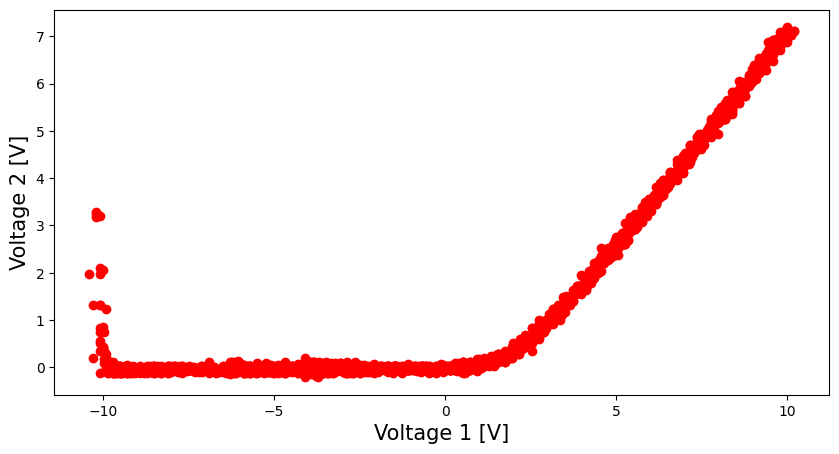

In [17]:

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(data['Volt1'], data['Volt2'], color='red')
ax.set_xlabel('Voltage 1 [V]', fontsize=fontsize)
ax.set_ylabel('Voltage 2 [V]', fontsize=fontsize)

plt.savefig('../tex/figures/part_1_XY.png', bbox_inches='tight')

### Current vs Applied Bias

In [18]:
2/5/2

0.2

In [19]:
data['Current (A)'] = data['Volt2'] / (10.05 * 10**(6))
data['dCurrent (A)'] = data['Current (A)'] * np.sqrt((0.2/data['Volt2'])**2 + (0.02*10**6/(10.05*10**6))**2)

<ErrorbarContainer object of 3 artists>

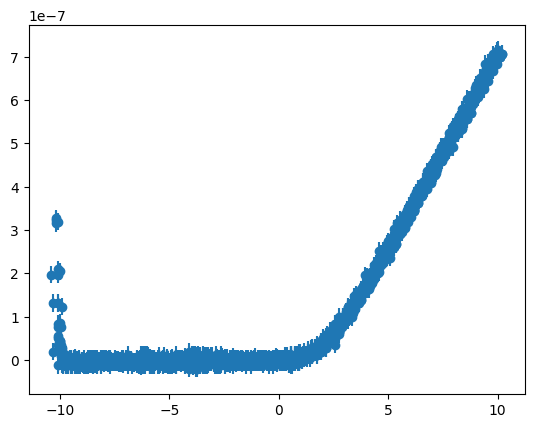

In [20]:
temp = data#.query('Volt1 <= 2 and Volt1 >= -7')
plt.errorbar(
    temp['Volt1'],
    temp['Current (A)'],
    yerr=temp['dCurrent (A)'].abs(),
    fmt='o'
)

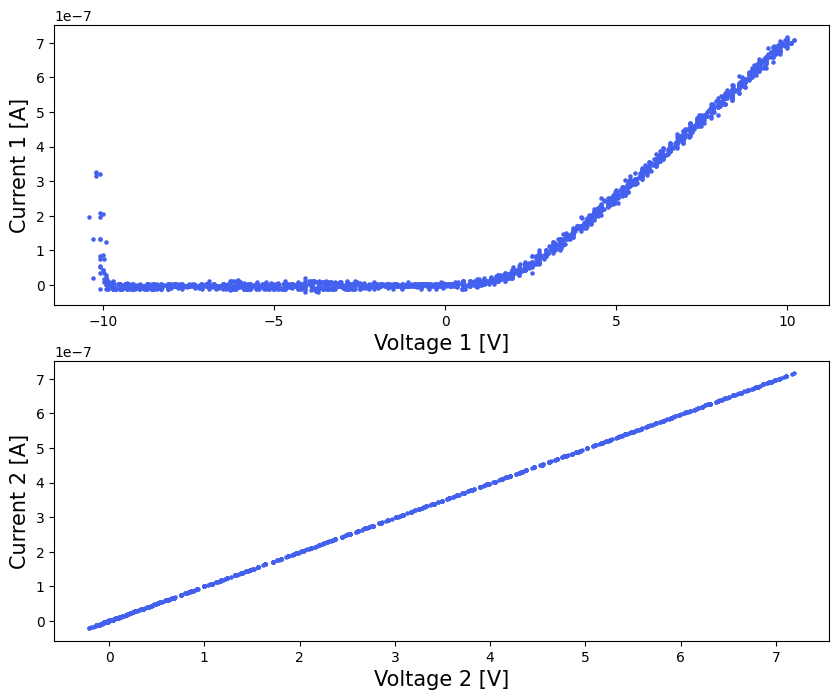

In [21]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
ax[0].scatter(
    data['Volt1'],
    data['Current (A)'],
    s=5,
    color='#4361ee',
)
ax[0].set_xlabel('Voltage 1 [V]', fontsize=fontsize)
ax[0].set_ylabel('Current 1 [A]', fontsize=fontsize)

ax[1].scatter(
    data['Volt2'],
    data['Current (A)'],
    s=5,   
    color='#4361ee', 
) 
ax[1].set_xlabel('Voltage 2 [V]', fontsize=fontsize)
ax[1].set_ylabel('Current 2 [A]', fontsize=fontsize)

plt.savefig('../data/part_1_current_vs_applied_bias.png')

In [22]:
# input voltage
v_in = 3.58 # Volts
dv_in = 0.01

# output voltage
v_out = -9.0262 # 
dv_out = 0.0010

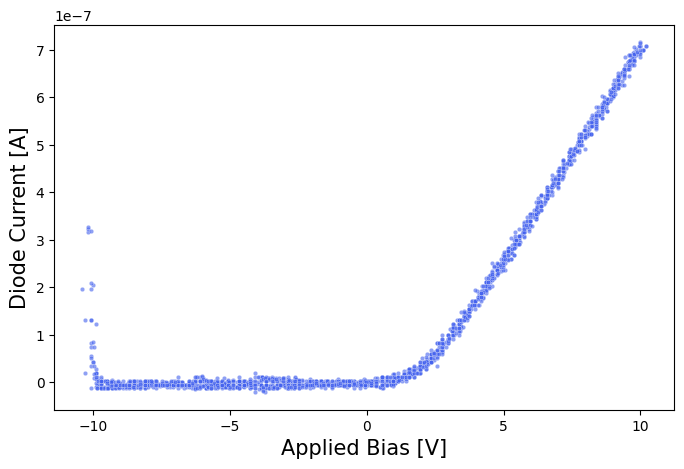

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.scatterplot(
    data,
    x='Volt1',
    y='Current (A)',
    alpha=0.6,
    s=10,
    color='#4361ee', 
)

ax.set_xlabel('Applied Bias [V]', fontsize=fontsize)
ax.set_ylabel('Diode Current [A]', fontsize=fontsize)
plt.savefig('../tex/figures/part_1_anode_current_vs_applied_bias.png', bbox_inches='tight')

In [24]:
5/5/2

0.5

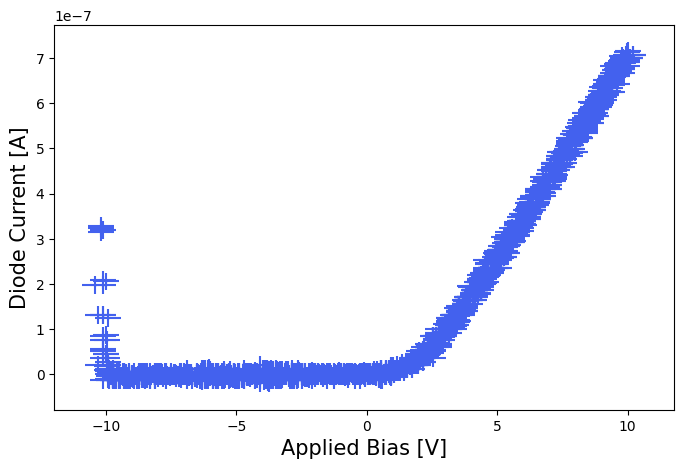

In [25]:
temp = data.copy()
temp['dVolt1'] = 3 / 100 * data['Volt1']
temp['dVolt2'] = 3 / 100 * data['Volt2']

plt.figure(figsize=(8, 5))
plt.errorbar(
    data['Volt1'],
    data['Current (A)'],
    yerr=temp['dCurrent (A)'].abs(),
    xerr=0.5,
    fmt='o',
    markersize=0.5,
    color='#4361ee', 
)
plt.xlabel(r'Applied Bias [V]', fontsize=fontsize)
plt.ylabel(r'Diode Current [A]', fontsize=fontsize)
plt.savefig('../tex/figures/part_1_anode_current_vs_applied_bias.png', bbox_inches='tight')

# Manually biased Franck Hertz experiment

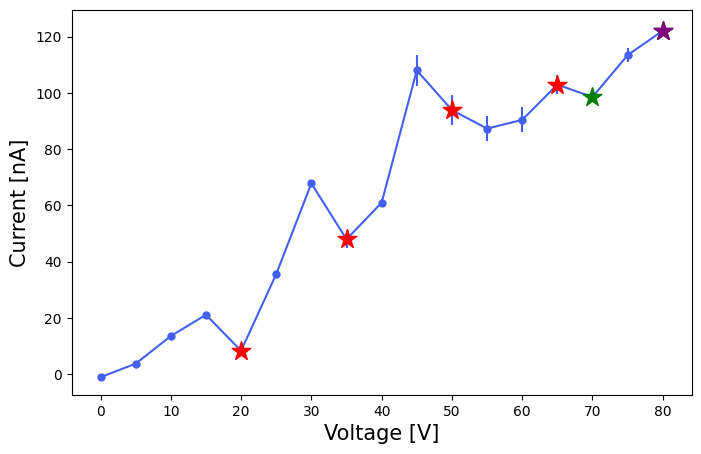

In [26]:
mb = pd.read_csv('../data/part3.txt', delimiter='\t')

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.errorbar(
    mb['V (V)'],
    mb['I (nA)'],
    xerr=mb['dV (V)'].abs(),
    yerr=mb['dI (nA)'].abs(),
    color='#4361ee', 
    fmt='o-',
    markersize=5,
)

clean_mb = mb[mb['cloud'].notna()].copy()[:4]
ax.scatter(
    clean_mb['V (V)'],
    clean_mb['I (nA)'],
    marker='*',
    c='red',
    s=200,
    zorder=5
)

clean_mb = mb[mb['cloud'].notna()].copy()[4:]
ax.scatter(
    clean_mb['V (V)'],
    clean_mb['I (nA)'],
    marker='*',
    c='green',
    s=200,
    zorder=10
)

clean_mb = mb[mb['cloud'].notna()].copy()[5:]
ax.scatter(
    clean_mb['V (V)'],
    clean_mb['I (nA)'],
    marker='*',
    c='purple',
    s=200,
    zorder=10
)
ax.set_xlabel('Voltage [V]', fontsize=fontsize)
ax.set_ylabel('Current [nA]', fontsize=fontsize)
plt.savefig('../tex/figures/part_3_I_vs_V.png', bbox_inches='tight')

# 5. Analysis

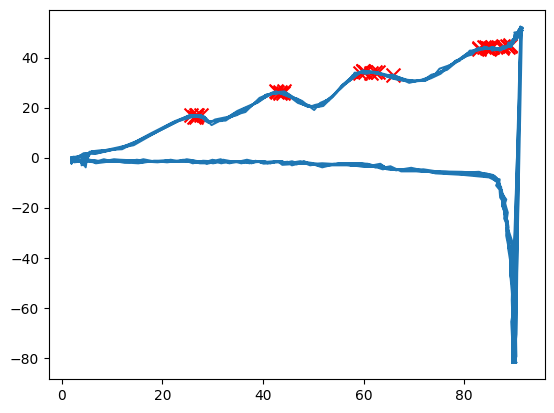

In [27]:
data1 = pd.read_csv('../data/scope_34.csv')
x1 = data1['Volt1']
y1 = data1['Volt2']

peaks, _ = find_peaks(y1, height=(3, 45), distance=2)

peak_x = data1['Volt1'][peaks]
peak_y = data1['Volt2'][peaks]

plt.plot(data1['Volt1'], data1['Volt2'])
plt.scatter(peak_x, peak_y, color='red', marker='x', s=100, label='Detected Peak')


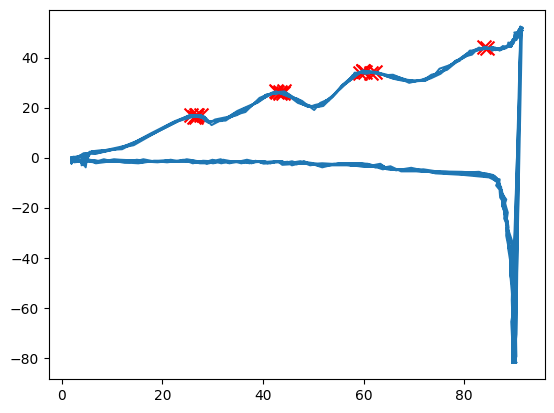

In [28]:
data1 = pd.read_csv('../data/scope_34.csv')
x1 = data1['Volt1']
y1 = data1['Volt2']

peaks, _ = find_peaks(y1, height=(3, 45), distance=2, prominence=1.2)

peak_x = data1['Volt1'][peaks]
peak_y = data1['Volt2'][peaks]

plt.plot(data1['Volt1'], data1['Volt2'])
plt.scatter(peak_x, peak_y, color='red', marker='x', s=100, label='Detected Peak')

,second,Volt1,Volt2,background,back-sub,dydx
0,-0.05000,1.944723,-1.468543,-2.305495,-0.836952,-0.000000e+00
1,-0.04995,1.944723,-1.267538,-2.305495,-1.037957,0.000000e+00
2,-0.04990,1.944723,-1.066533,-2.305495,-1.238962,-8.881784e-16
8,-0.04960,1.944723,-0.664523,-2.305495,-1.640972,0.000000e+00
9,-0.04955,1.944723,-0.865528,-2.305495,-1.439967,-1.110223e-15
...,...,...,...,...,...,...
1980,0.04900,1.944723,-1.468543,-2.305495,-0.836952,0.000000e+00
1985,0.04925,1.944723,-0.664523,-2.305495,-1.640972,0.000000e+00
1989,0.04945,1.944723,-1.066533,-2.305495,-1.238962,0.000000e+00
1994,0.04970,1.944723,-1.468543,-2.305495,-0.836952,-8.881784e-16


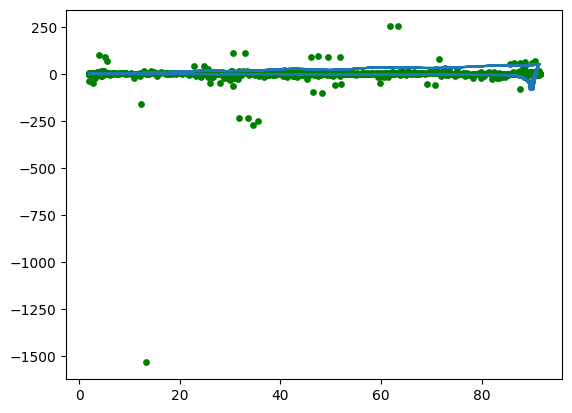

In [29]:
data1['background'] = 0.0001 * data1['Volt1']**3 - 0.0145 * data1['Volt1']**2 + 1.0437 * data1['Volt1'] - 4.2811
data1['back-sub'] = data1['background'] - data1['Volt2']
data1['dydx'] = np.gradient(data1['Volt1'], data1['back-sub'])

temp = data1.query('dydx.notna() and dydx != inf and dydx != -inf')
plt.plot(data1['Volt1'], data1['Volt2'])
plt.scatter(temp['Volt1'], temp['dydx'], s=15, c='green')
temp

Fitted parameters: A=1.399, B=1.158, C=-6.529, D=-1.597


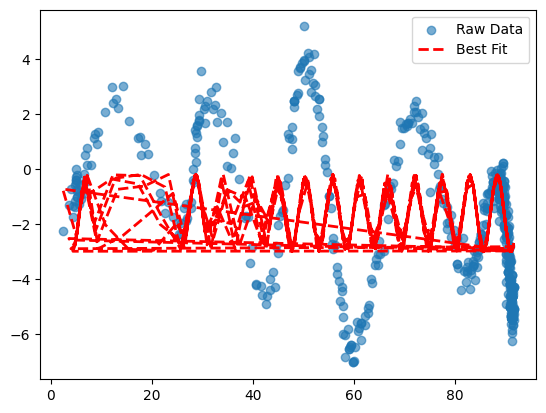

In [30]:
# plt.scatter(x1[y1>0.2], y1[y1 > 0.2])
bkg_sub = data1['back-sub']
x = x1[y1 > 0.2]
y = bkg_sub[y1 > 0.2]
# plt.scatter(x, y)
plt.show()


def sine_function(x, A, B, C, D):
    '''
    Sinusoidal function for curve fitting.
    
    Params
    ------
    A: Amplitude
    B: Angular frequency (omega)
    C: Phase Shift
    D: Vertical Offset
    '''
    return A * np.sin(B * x + C) + D

initial_guesses = [
    1, 1, 0, 225234
]
optimal_params, param_covariance = curve_fit(sine_function, x, y, p0=initial_guesses)
A_fit, B_fit, C_fit, D_fit = optimal_params
y_fit = sine_function(x, *optimal_params)
print(f"Fitted parameters: A={A_fit:.3f}, B={B_fit:.3f}, C={C_fit:.3f}, D={D_fit:.3f}")
plt.scatter(x, y, label='Raw Data', alpha=0.6)
plt.plot(x, y_fit, 'r--', label='Best Fit', linewidth=2)
plt.legend()

C:\Users\devkh\AppData\Local\Temp\ipykernel_12416\2673981467.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp_ = temp[temp['Volt1'] < 2.69][temp['Volt1'] > 2]


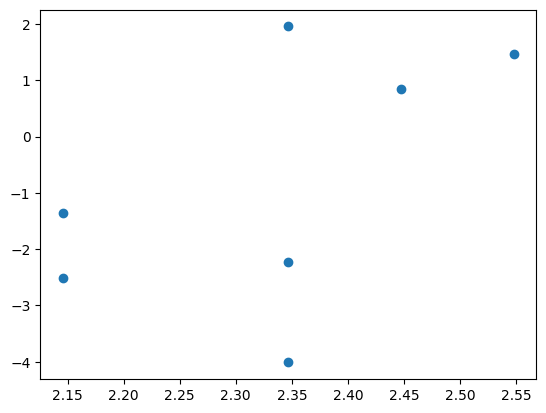

In [31]:
temp_ = temp[temp['Volt1'] < 2.69][temp['Volt1'] > 2]

plt.scatter(temp_['Volt1'], temp_['dydx'])

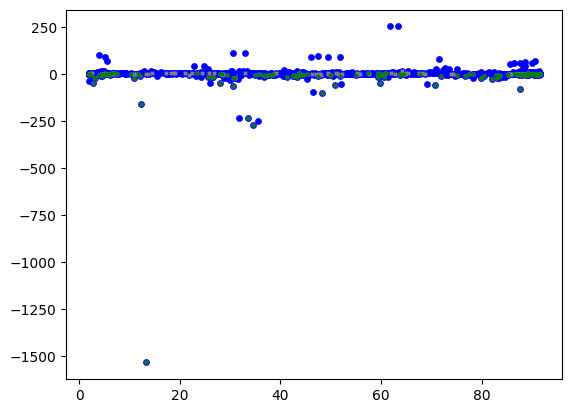

In [32]:
from scipy.signal import argrelextrema

minima = argrelextrema(temp['dydx'].to_numpy(), np.less)[0]
minima_, _ = find_peaks(-temp['dydx'].to_numpy(), prominence=1)

minima
plt.scatter(temp['Volt1'], temp['dydx'], s=15, c='blue')
plt.scatter(temp['Volt1'].to_numpy()[minima], temp['dydx'].to_numpy()[minima], s=5, marker='x', color='gray')
plt.scatter(temp['Volt1'].to_numpy()[minima_], temp['dydx'].to_numpy()[minima_], s=5, marker='*', color='green')

In [33]:
data1

,second,Volt1,Volt2,background,back-sub,dydx
0,-0.05000,1.944723,-1.468543,-2.305495,-0.836952,-0.000000e+00
1,-0.04995,1.944723,-1.267538,-2.305495,-1.037957,0.000000e+00
2,-0.04990,1.944723,-1.066533,-2.305495,-1.238962,-8.881784e-16
3,-0.04985,1.944723,-1.468543,-2.305495,-0.836952,NaN
4,-0.04980,1.944723,-1.468543,-2.305495,-0.836952,NaN
...,...,...,...,...,...,...
1995,0.04975,1.944723,-1.267538,-2.305495,-1.037957,-1.110223e-15
1996,0.04980,1.944723,-0.664523,-2.305495,-1.640972,NaN
1997,0.04985,1.944723,-0.664523,-2.305495,-1.640972,NaN
1998,0.04990,1.944723,-1.468543,-2.305495,-0.836952,NaN


,second,Volt1,Volt2,Unnamed: 3,x and y are 10 times too big because the oscilloscope wa set to a different 10:1 probe. Also off a factor of 10 writ in lab book
0,-0.000500,4.90,0.180,NaN,NaN
1,-0.000500,4.49,-0.222,NaN,NaN
2,-0.000499,4.70,-0.222,NaN,NaN
3,-0.000499,4.90,-0.222,NaN,NaN
4,-0.000498,4.09,0.180,NaN,NaN


661     23.8
779     25.4
1644    40.7
1648    40.3
1695    40.3
1711    41.1
1716    41.5
1720    41.1
1737    41.5
Name: Volt1, dtype: float64

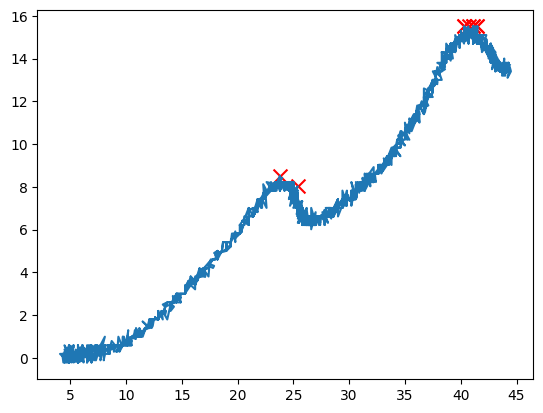

In [34]:
data2 = pd.read_csv('../data/scope_26.csv')
display(data2.head())
x2 = data2['Volt1']
y2 = data2['Volt2']
plt.plot(x2, y2)

peaks, _ = find_peaks(y2, height=6, prominence=0.9)
peak_x = x2[peaks]
peak_y = y2[peaks]

plt.scatter(peak_x, peak_y, color='red', marker='x', s=100, label='Detected Peak')
peak_x

,second,Volt1,Volt2
0,-0.05000,-0.191155,-2.025126
1,-0.04995,-0.191155,-1.824121
2,-0.04990,-0.191155,-1.221106
3,-0.04985,-0.593165,-1.422111
4,-0.04980,-0.191155,-1.221106


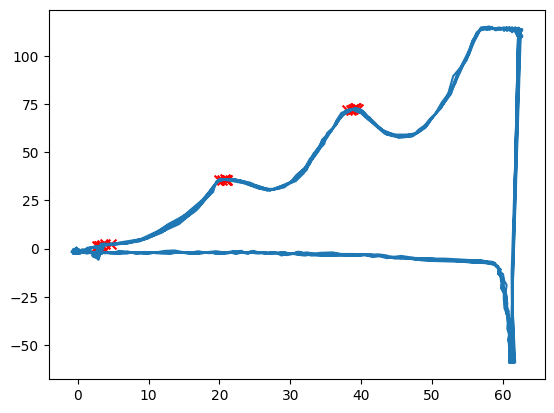

In [35]:
data3 = pd.read_csv('../data/scope_33.csv')
display(data3.head())
x3 = data3['Volt1']
y3 = data3['Volt2']

peaks, _ = find_peaks(y3, height=1)
x_peak = x3[peaks]
y_peak = y3[peaks]
plt.scatter(x_peak[y_peak < 100], y_peak[y_peak < 100], marker='x', s=50, c='red')
plt.plot(x3, y3)
plt.show()

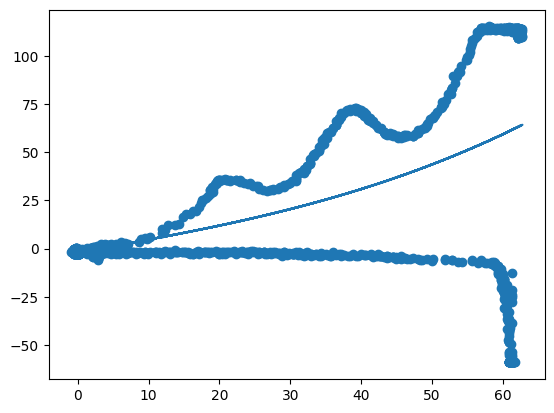

In [36]:
coeffs = np.polyfit(x3, y3, 3)
poly = np.poly1d(coeffs)

plt.scatter(x3, y3)
plt.plot(x3, poly(x3))

## Franck Hertz plot

<ErrorbarContainer object of 3 artists>

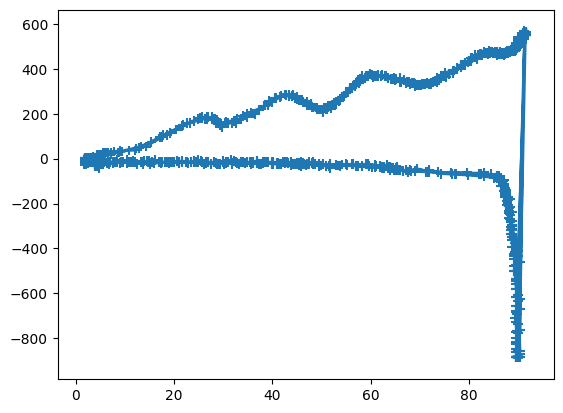

In [37]:
plt.errorbar(
    data1['Volt1'],
    data1['Volt2'] * 10.8,
    xerr=1,
    yerr=data1['Volt2'].abs()*10.8*np.sqrt((2/data1['Volt2'].abs())**2 + (0.1/10.8)**2)
)

In [38]:
data1['Current (nA)'] = data1['Volt2'] * 10.8
data1['dCurrent (nA)'] = data1['Current (nA)'] * np.sqrt((0.1/10.8)**2 + (2/data1['Volt2'])**2)


In [39]:
-1.46 * 10.8 * np.sqrt((0.1/10.8)**2 + (2/-1.46)**2)


np.float64(-21.600493420290196)

In [40]:
data1

,second,Volt1,Volt2,background,back-sub,dydx,Current (nA),dCurrent (nA)
0,-0.05000,1.944723,-1.468543,-2.305495,-0.836952,-0.000000e+00,-15.860266,-21.600499
1,-0.04995,1.944723,-1.267538,-2.305495,-1.037957,0.000000e+00,-13.689411,-21.600372
2,-0.04990,1.944723,-1.066533,-2.305495,-1.238962,-8.881784e-16,-11.518557,-21.600263
3,-0.04985,1.944723,-1.468543,-2.305495,-0.836952,NaN,-15.860266,-21.600499
4,-0.04980,1.944723,-1.468543,-2.305495,-0.836952,NaN,-15.860266,-21.600499
...,...,...,...,...,...,...,...,...
1995,0.04975,1.944723,-1.267538,-2.305495,-1.037957,-1.110223e-15,-13.689411,-21.600372
1996,0.04980,1.944723,-0.664523,-2.305495,-1.640972,NaN,-7.176849,-21.600102
1997,0.04985,1.944723,-0.664523,-2.305495,-1.640972,NaN,-7.176849,-21.600102
1998,0.04990,1.944723,-1.468543,-2.305495,-0.836952,NaN,-15.860266,-21.600499


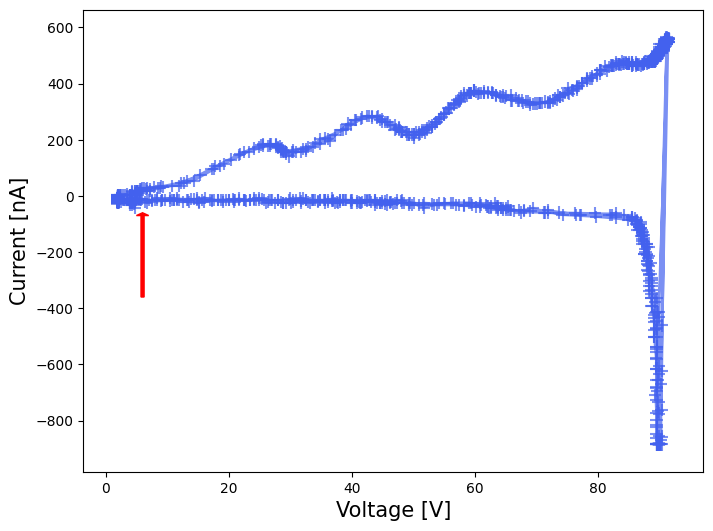

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.errorbar(
    data1['Volt1'],
    data1['Current (nA)'],
    alpha=0.7,
    color='#4361ee',
    xerr=1,
    yerr=data1['dCurrent (nA)'].abs()
)

ax.set_xlabel('Voltage [V]', fontsize=fontsize)
ax.set_ylabel('Current [nA]', fontsize=fontsize)

plt.arrow(6, -360, 0, 300, width=0.5, head_width=2, head_length=10, color='red', length_includes_head=True)
# plt.scatter(
#     [26.7, 42.7, 59.9, 83.4],
#     [180, 283, 370, 470],
#     marker='x',
#     color='red',
#     s=100
# )

plt.savefig('../tex/figures/part_4_data.png', bbox_inches='tight')

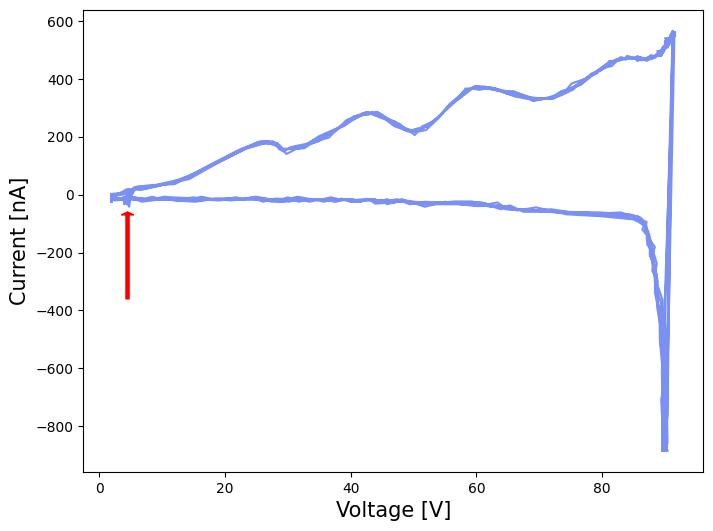

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(
    data1['Volt1'],
    data1['Volt2'] * 10.8,
    alpha=0.7,
    color='#4361ee', 
)

ax.set_xlabel('Voltage [V]', fontsize=fontsize)
ax.set_ylabel('Current [nA]', fontsize=fontsize)

plt.arrow(4.5, -360, 0, 300, width=0.5, head_width=2, head_length=10, color='red', length_includes_head=True)
# plt.scatter(
#     [26.7, 42.7, 59.9, 83.4],
#     [180, 283, 370, 470],
#     marker='x',
#     color='red',
#     s=100
# )

# plt.savefig('../tex/figures/part_4_data.png', bbox_inches='tight')

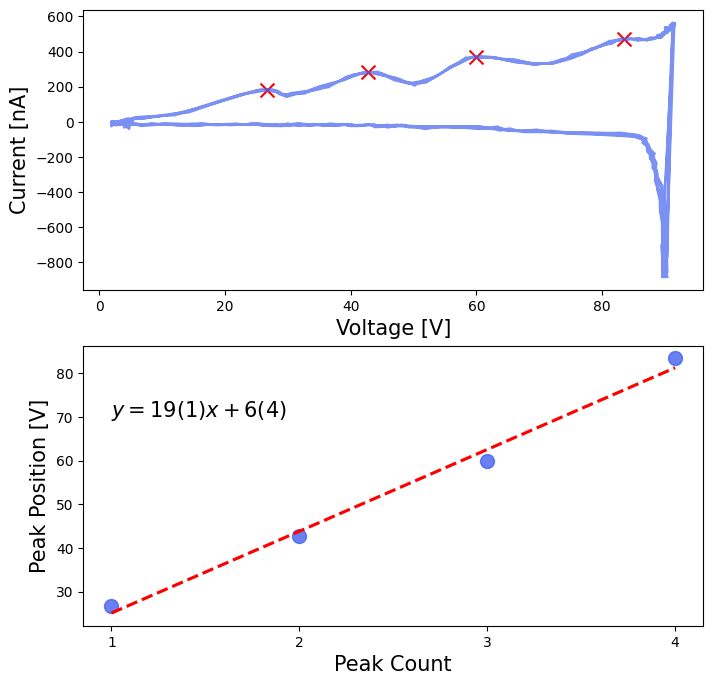

In [43]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.errorbar(
    data1['Volt1'],
    data1['Volt2'] * 10.8,
    alpha=0.7,
    color='#4361ee', 
)

ax1.set_xlabel('Voltage [V]', fontsize=fontsize)
ax1.set_ylabel('Current [nA]', fontsize=fontsize)

ax1.scatter(
    [26.7, 42.7, 59.9, 83.4],
    [180, 283, 370, 470],
    marker='x',
    color='red',
    s=100
)

peak_ind = [1, 2, 3, 4]
peak_pos = [26.7, 42.7, 59.9, 83.4]
sns.regplot(
    x=peak_ind,
    y=peak_pos,
    scatter_kws={'color': '#4361ee', 's': 100, },
    line_kws={'color': 'red', 'linestyle': "--"},
    ci=None,
    ax=ax2
)
ax2.text(1, 70, r'$y = 19(1)x + 6(4)$', fontsize=fontsize)
ax2.set_xlabel('Peak Count', fontsize=fontsize)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_ylabel('Peak Position [V]', fontsize=fontsize)

plt.savefig('../tex/figures/part_5_data.png')

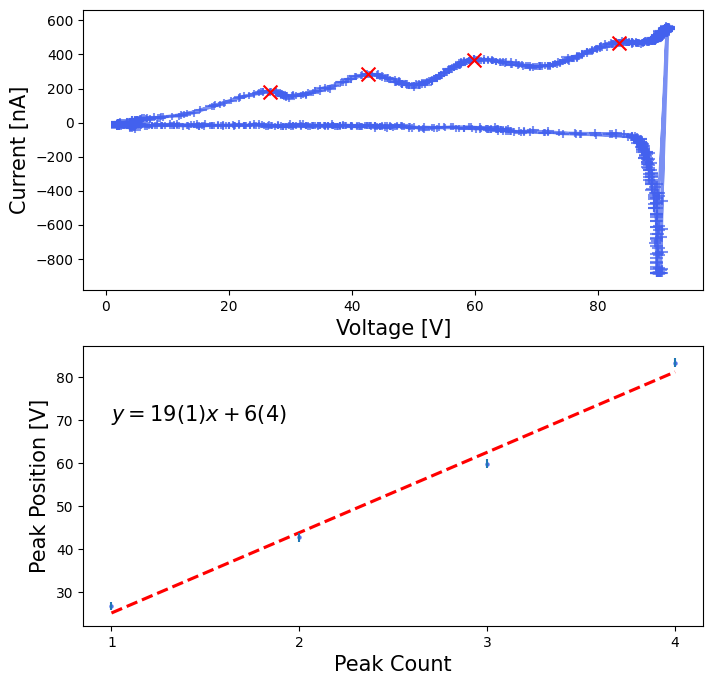

In [44]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.errorbar(
    data1['Volt1'],
    data1['Current (nA)'],
    xerr=1,
    yerr=data1['dCurrent (nA)'].abs(),
    alpha=0.7,
    color='#4361ee', 
)

ax1.set_xlabel('Voltage [V]', fontsize=fontsize)
ax1.set_ylabel('Current [nA]', fontsize=fontsize)

ax1.scatter(
    [26.7, 42.7, 59.9, 83.4],
    [180, 283, 370, 470],
    marker='x',
    color='red',
    s=100,
    zorder=15
)

peak_ind = [1, 2, 3, 4]
peak_pos = [26.7, 42.7, 59.9, 83.4]
sns.regplot(
    x=peak_ind,
    y=peak_pos,
    scatter_kws={'color': '#4361ee', 's': 5, },
    line_kws={'color': 'red', 'linestyle': "--"},
    ci=None,
    ax=ax2
)
# ax2.errorbar(
#     peak_ind,
#     peak_pos,
#     fmt='none',
#     yerr=1
# )
ax2.errorbar(
    peak_ind,
    peak_pos,
    yerr=1,
    fmt='none'
)
ax2.text(1, 70, r'$y = 19(1)x + 6(4)$', fontsize=fontsize)
ax2.set_xlabel('Peak Count', fontsize=fontsize)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_ylabel('Peak Position [V]', fontsize=fontsize)

plt.savefig('../tex/figures/part_5_data.png', bbox_inches='tight')

Text(0, 0.5, 'Peak Position [V]')

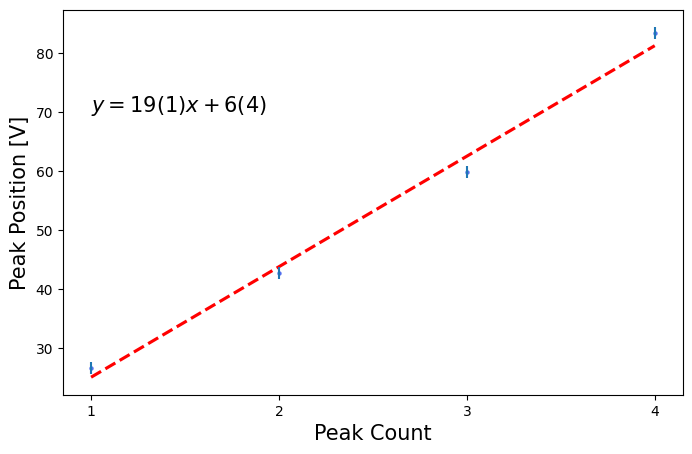

In [45]:
peak_ind = [1, 2, 3, 4]
peak_pos = [26.7, 42.7, 59.9, 83.4]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
# ax.scatter(
#     peak_ind, 
#     peak_pos,
#     color='#4361ee',,
#     alpha=0.7, 
# )
sns.regplot(
    x=peak_ind,
    y=peak_pos,
    scatter_kws={'color': '#4361ee', 's': 5, },
    line_kws={'color': 'red', 'linestyle': "--"},
    ci=None
)
ax.errorbar(
    peak_ind,
    peak_pos,
    yerr=1,
    fmt='none'
)
ax.text(1, 70, r'$y = 19(1)x + 6(4)$', fontsize=fontsize)
ax.set_xlabel('Peak Count', fontsize=fontsize)
ax.set_xticks([1, 2, 3, 4])
ax.set_ylabel('Peak Position [V]', fontsize=fontsize)

## Step 3

In [46]:
# d1 = '''
# 2.33E+01	1.46E+01
# 2.42E+01	1.56E+01
# 2.53E+01	1.68E+01
# 2.67E+01	1.70E+01
# 2.77E+01	1.68E+01
# 2.81E+01	1.62E+01
# 2.86E+01	1.46E+01
# '''

d1 = '''
2.33E+01	1.46E+01	157.1245722645	21.5827338079
2.42E+01	1.56E+01	167.8865292689	21.5910542971
2.53E+01	1.68E+01	180.8008776742	21.6017615193
2.67E+01	1.70E+01	182.9532690750	21.6036226244
2.77E+01	1.68E+01	180.8008776742	21.6017615193
2.81E+01	1.62E+01	174.3437034715	21.5963094306
2.86E+01	1.46E+01	157.1245722645	21.5827338079
'''
peak1 = pd.read_csv(io.StringIO(d1.strip()), sep='\s+', names=['x', 'y', 'y_', 'dy_'])


# d2 = '''
# 3.90E+01	2.20E+01
# 3.98E+01	2.35E+01
# 4.17E+01	2.59E+01
# 4.27E+01	2.63E+01
# 4.46E+01	2.51E+01
# 4.50E+01	2.45E+01
# 4.63E+01	2.35E+01
# '''

d2 = ''' 
3.90E+01	2.20E+01	2.37E+02	2.17E+01
3.98E+01	2.35E+01	2.53E+02	2.17E+01
4.17E+01	2.59E+01	2.79E+02	2.17E+01
4.27E+01	2.63E+01	2.83E+02	2.17E+01
4.46E+01	2.51E+01	2.70E+02	2.17E+01
4.50E+01	2.45E+01	2.64E+02	2.17E+01
4.63E+01	2.35E+01	2.53E+02	2.17E+01


'''

peak2 = pd.read_csv(io.StringIO(d2.strip()), sep='\s+', names=['x', 'y', 'y_', 'dy_'])

d3 = '''
5.78E+01	3.29E+01	3.54E+02	2.18E+01
5.82E+01	3.31E+01	3.56E+02	2.18E+01
5.90E+01	3.39E+01	3.65E+02	2.18E+01
5.99E+01	3.47E+01	3.73E+02	2.19E+01
6.07E+01	3.39E+01	3.65E+02	2.18E+01
6.35E+01	3.31E+01	3.56E+02	2.18E+01
6.43E+01	3.27E+01	3.52E+02	2.18E+01
'''
peak3 = pd.read_csv(io.StringIO(d3.strip()), sep='\s+', names=['x', 'y', 'y_', 'dy_'])

d4 = ''' 
8.15E+01	4.11E+01	4.42E+02	2.20E+01
8.26E+01	4.28E+01	4.61E+02	2.20E+01
8.36E+01	4.34E+01	4.67E+02	2.20E+01
8.40E+01	4.44E+01	4.78E+02	2.21E+01
8.46E+01	4.40E+01	4.73E+02	2.21E+01
8.52E+01	4.36E+01	4.69E+02	2.20E+01
8.56E+01	4.28E+01	4.61E+02	2.20E+01
'''
peak4 = pd.read_csv(io.StringIO(d4.strip()), sep='\s+', names=['x', 'y', 'y_', 'dy_'])

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\s'
C:\Users\devkh\AppData\Local\Temp\ipykernel_12416\2279143417.py:20: SyntaxWarning: invalid escape sequence '\s'
  peak1 = pd.read_csv(io.StringIO(d1.strip()), sep='\s+', names=['x', 'y', 'y_', 'dy_'])
C:\Users\devkh\AppData\Local\Temp\ipykernel_12416\2279143417.py:45: SyntaxWarning: invalid escape sequence '\s'
  peak2 = pd.read_csv(io.StringIO(d2.strip()), sep='\s+', names=['x', 'y', 'y_', 'dy_'])
C:\Users\devkh\AppData\Local\Temp\ipykernel_12416\2279143417.py:56: SyntaxWarning: invalid escape sequence '\s'
  peak3 = pd.read_csv(io.StringIO(d3.strip()), sep='\s+', names=['x', 'y', 'y_

Text(0.02, 0.5, '$V_p$ [nA]')

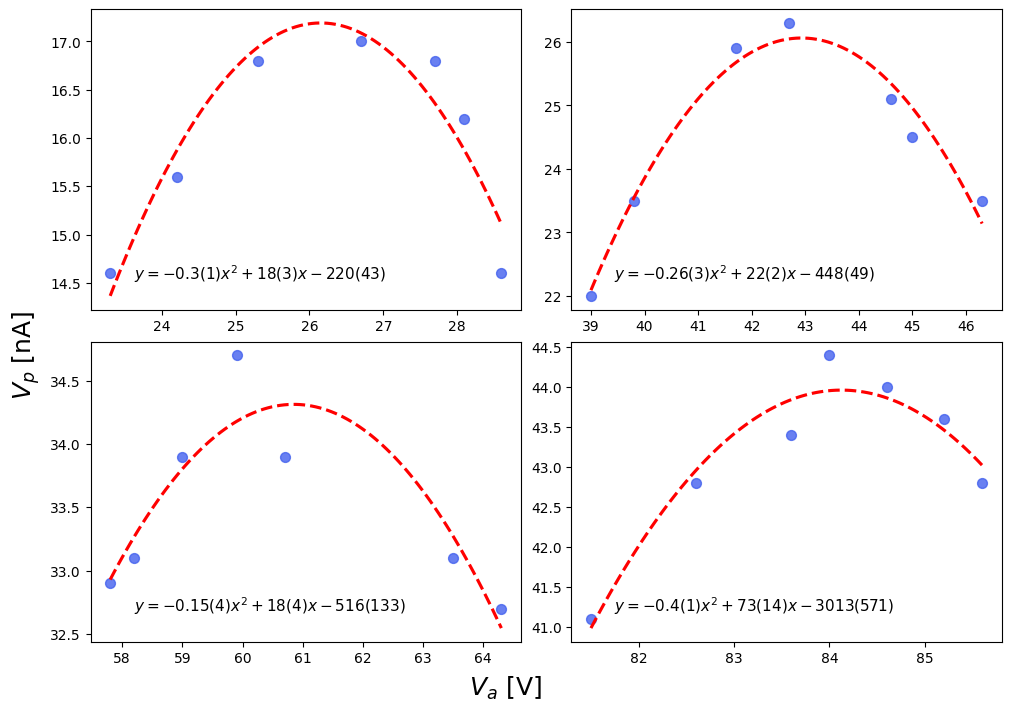

In [47]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True,)

temp = [peak1, peak2, peak3, peak4]
best_fit_eq = [
    r'$y=-0.3(1)x^2 +18(3)x -220(43)$',
    r'$y=-0.26(3)x^2+22(2)x-448(49)$',
    r'$y=-0.15(4)x^2+18(4)x-516(133)$',
    r'$y=-0.4(1)x^2+73(14)x-3013(571)$'
]

def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

for i, ax in enumerate(axs.flatten()):
    popt, pcov = curve_fit(quadratic_func, temp[i]['x'], temp[i]['y'])
    a, b, c = popt
    a_err, b_err, c_err = np.sqrt(np.diag(pcov))
    sns.regplot(
        x=temp[i]['x'],
        y=temp[i]['y'],
        ax=ax,
        order=2,
        ci=None,
        scatter_kws={'color': '#4361ee', 's': 50, },
        line_kws={'color': 'red', 'linestyle': "--"}
    )
    ax.text(
        0.1, 0.1,
        best_fit_eq[i],
        transform=ax.transAxes,
        fontsize=11
        )

    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.label_outer()


fig.supxlabel(r'$V_a$ [V]', fontsize=fontsize+3)
fig.supylabel(r'$V_p$ [nA]', fontsize=fontsize+3)


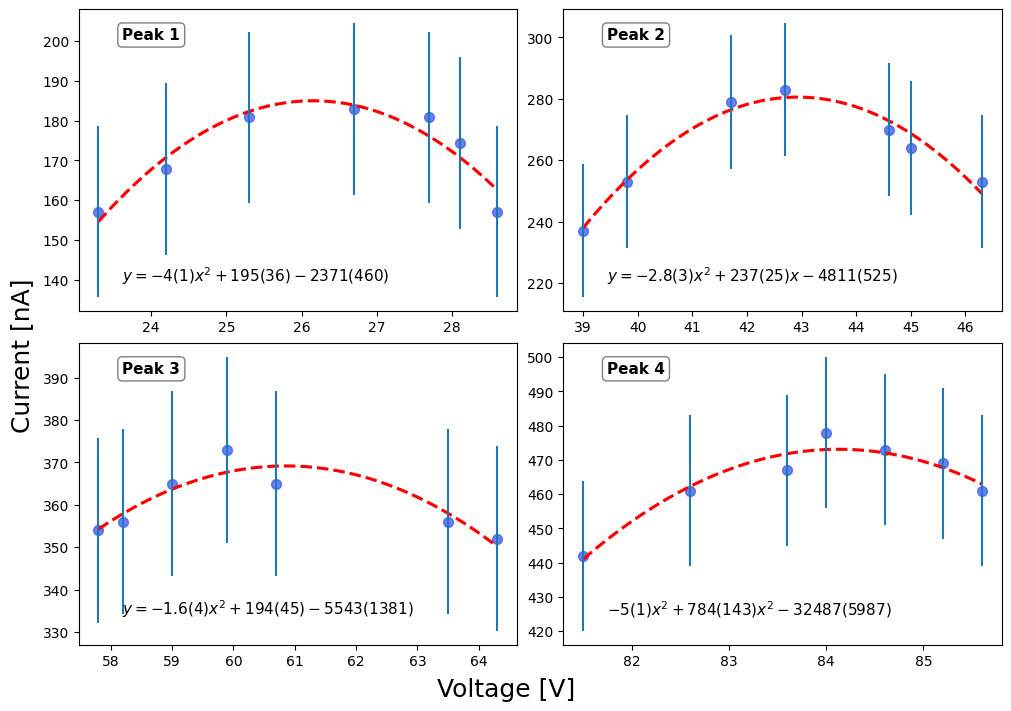

In [48]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True,)

temp = [peak1, peak2, peak3, peak4]
temp_text = ['Peak 1', "Peak 2", "Peak 3", "Peak 4"]
best_fit_eq = [
    r'$y=-4(1)x^2 + 195(36) -2371(460)$',
    r'$y=-2.8(3)x^2+237(25)x-4811(525)$',
    r'$y=-1.6(4)x^2+194(45)-5543(1381)$',
    r'$-5(1)x^2+784(143)x^2-32487(5987)$',
]

def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

for i, ax in enumerate(axs.flatten()):
    popt, pcov = curve_fit(quadratic_func, temp[i]['x'], temp[i]['y_'])
    a, b, c = popt
    a_err, b_err, c_err = np.sqrt(np.diag(pcov))
    sns.regplot(
        x=temp[i]['x'],
        y=temp[i]['y_'],
        ax=ax,
        order=2,
        ci=None,
        scatter_kws={'color': '#4361ee', 's': 50, },
        line_kws={'color': 'red', 'linestyle': "--"}
    )
    ax.errorbar(
        temp[i]['x'],
        temp[i]['y_'],
        yerr=temp[i]['dy_'].abs(),
        fmt='None'
    )

    ax.text(
        0.1, 0.1,
        best_fit_eq[i],
        transform=ax.transAxes,
        fontsize=11
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    box_props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    ax.text(0.1, 0.9,
             f'{temp_text[i]}',
             transform=ax.transAxes,
             fontsize=11,
             fontweight='bold',
             bbox=box_props
             )


fig.supxlabel('Voltage [V]', fontsize=fontsize+3)
fig.supylabel('Current [nA]', fontsize=fontsize+3)
plt.savefig('../tex/figures/part_5_quadratic_fit_each_peak.png', bbox_inches='tight')


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\devkh\AppData\Local\Temp\ipykernel_12416\517558174.py:7: SyntaxWarning: invalid escape sequence '\s'
  step3 = pd.read_csv(io.StringIO(step3_data.strip()), sep='\s+', names=['x', 'y'])


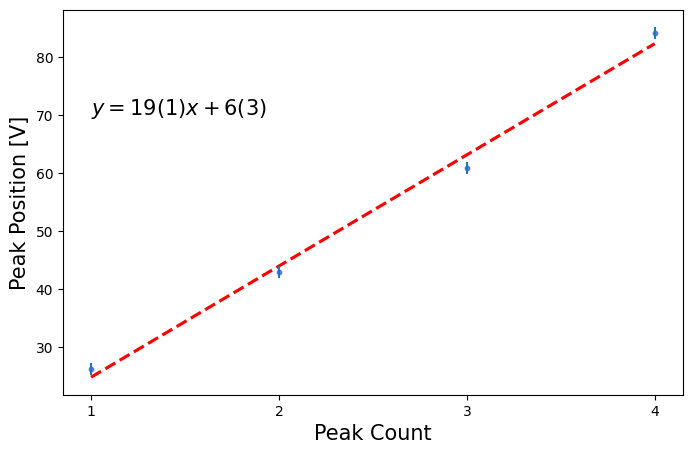

In [49]:
step3_data = ''' 
1	26.15193193
2	42.93038706
3	60.83931089
4	84.10902546
'''
step3 = pd.read_csv(io.StringIO(step3_data.strip()), sep='\s+', names=['x', 'y'])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

sns.regplot(
    x=step3['x'],
    y=step3['y'],
    scatter_kws={'color': '#4361ee', 's': 10, },
    line_kws={'color': 'red', 'linestyle': "--"},
    ci=None
)
ax.errorbar(
    step3['x'],
    step3['y'],
    fmt='none',
    yerr=1,
    markersize=3
)
ax.text(1, 70, r'$y = 19(1)x + 6(3)$', fontsize=fontsize)
ax.set_xlabel('Peak Count', fontsize=fontsize)
ax.set_xticks([1, 2, 3, 4])
ax.set_ylabel('Peak Position [V]', fontsize=fontsize)
plt.savefig('../tex/figures/part_5_step_3.png')

## Step 4

In [50]:
step4 = pd.read_csv('../data/part5_step4.txt', delimiter='\t')
step4

,second,Volt1,Volt2,clean,background,clean-back,dR/dN
0,-0.05000,1.94,-1.47,NaN,-2.31,NaN,NaN
1,-0.05000,1.94,-1.27,NaN,-2.31,NaN,NaN
2,-0.04990,1.94,-1.07,NaN,-2.31,NaN,NaN
3,-0.04990,1.94,-1.47,NaN,-2.31,NaN,NaN
4,-0.04980,1.94,-1.47,NaN,-2.31,NaN,NaN
...,...,...,...,...,...,...,...
1995,0.00660,91.60,51.60,51.596784,46.50,5.09,#DIV/0!
1996,0.00665,91.60,51.80,51.797789,46.50,5.29,#DIV/0!
1997,0.02300,91.60,50.80,50.792764,46.50,4.28,#DIV/0!
1998,0.03980,91.60,50.80,50.792764,46.50,4.28,#DIV/0!


In [51]:
step4['Current'] = step4['clean'] * 10.8
step4['dCurrent'] = step4['Current'] * np.sqrt((0.1/10.8)**2 + (2/step4['clean'])**2)

In [52]:
tempdf = step4.query('Current.notna()').reset_index()
tempdf

,index,second,Volt1,Volt2,clean,background,clean-back,dR/dN,Current,dCurrent
0,1021,-0.01470,2.35,0.341,0.340502,-1.910000,2.250,NaN,3.677423,21.600027
1,1031,0.01870,3.55,0.542,0.541507,-0.752000,1.290,NaN,5.848277,21.600068
2,1034,-0.03130,3.95,0.341,0.340502,-0.374000,0.715,NaN,3.677423,21.600027
3,1047,-0.04790,4.36,1.350,1.345527,-0.000888,1.350,NaN,14.531694,21.600419
4,1057,0.03540,4.36,1.750,1.747537,-0.000888,1.750,NaN,18.873403,21.600707
...,...,...,...,...,...,...,...,...,...,...
533,1995,0.00660,91.60,51.600,51.596784,46.500000,5.090,#DIV/0!,557.245267,22.207708
534,1996,0.00665,91.60,51.800,51.797789,46.500000,5.290,#DIV/0!,559.416121,22.212386
535,1997,0.02300,91.60,50.800,50.792764,46.500000,4.280,#DIV/0!,548.561849,22.189165
536,1998,0.03980,91.60,50.800,50.792764,46.500000,4.280,#DIV/0!,548.561849,22.189165


Fitted Coefficients (a3, a2, a1, a0): [ 1.11443202e-03 -1.55250279e-01  1.12243895e+01 -4.58779926e+01]
Uncertainties (std. error)          : [7.34018090e-05 1.11996980e-02 4.78800991e-01 5.43534537e+00]


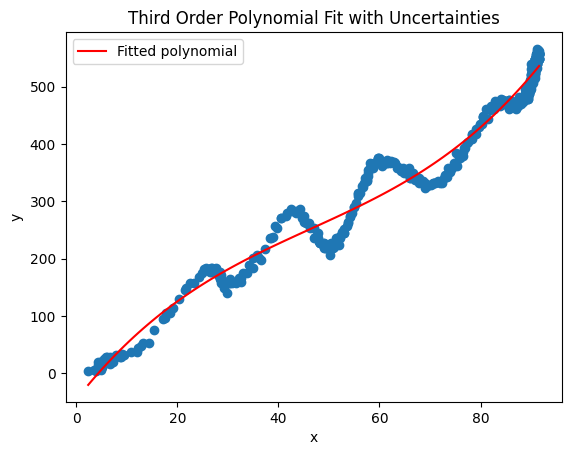

In [53]:
x = tempdf['Volt1']
y = tempdf['Current']
def third_order_poly(x, a3, a2, a1, a0):
    """A third-order polynomial function: a3*x^3 + a2*x^2 + a1*x + a0"""
    return a3 * x**3 + a2 * x**2 + a1 * x + a0

popt, pcov = curve_fit(third_order_poly, x, y, sigma=tempdf['dCurrent'], absolute_sigma=True)

coefficients = popt
uncertainties = np.sqrt(np.diag(pcov))
print(f"Fitted Coefficients (a3, a2, a1, a0): {coefficients}")
print(f"Uncertainties (std. error)          : {uncertainties}")
x_plot = np.linspace(min(x), max(x), 100)
y_fit = third_order_poly(x_plot, *coefficients)
plt.scatter(x, y)
plt.plot(x_plot, y_fit, 'r-', label='Fitted polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Third Order Polynomial Fit with Uncertainties')
plt.legend()
plt.show()

Fitted Coefficients (a3, a2, a1, a0): [ 1.11443202e-03 -1.55250279e-01  1.12243895e+01 -4.58779926e+01]
Uncertainties (std. error)          : [7.34018090e-05 1.11996980e-02 4.78800991e-01 5.43534537e+00]


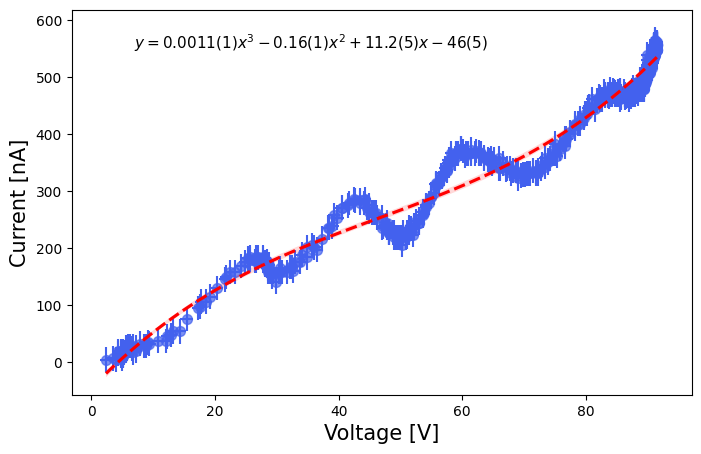

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.regplot(
    x=step4['Volt1'],
    y=step4['Current'], 
    order=3,
    ci=95,
    scatter_kws={'color': '#4361ee', 's': 50, 'alpha': 0.7},
    line_kws={'color': 'red', 'linestyle': "--"},
)
ax.set_xlabel('Voltage [V]', fontsize=fontsize)
ax.set_ylabel('Current [nA]', fontsize=fontsize)
ax.errorbar(
    step4['Volt1'],
    step4['Current'],
    xerr=1,
    yerr=step4['dCurrent'],
    fmt='none',
    color='#4361ee',
    zorder=1
)
ax.text(0.1, 0.9,
             r'$y=0.0011(1)x^3 -0.16(1)x^2+11.2(5)x-46(5)$',
             transform=ax.transAxes,
             fontsize=11,
            #  fontweight='bold',
            #  bbox=box_props
             )
print(f"Fitted Coefficients (a3, a2, a1, a0): {coefficients}")
print(f"Uncertainties (std. error)          : {uncertainties}")
plt.savefig('../tex/figures/step_5_part_4_background_fit.png', bbox_inches='tight')

Text(0, 0.5, 'Background subtracted Current [nA]')

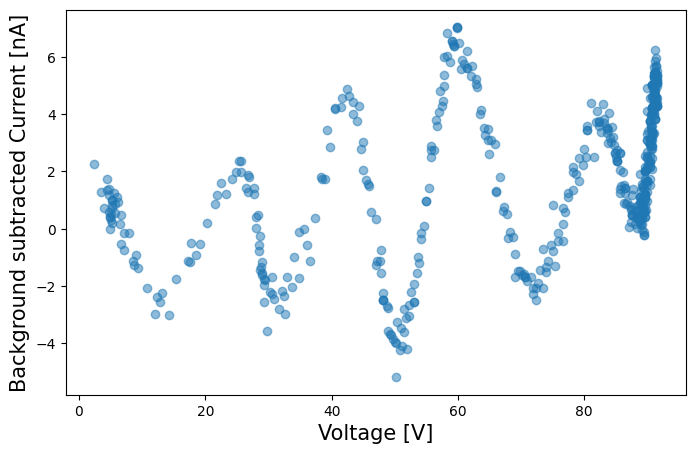

In [61]:
plt.figure(figsize=(8, 5))
plt.scatter(step4['Volt1'], step4['clean-back'], alpha=0.5)
plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Background subtracted Current [nA]', fontsize=fontsize)


In [171]:
d5 = '''
1	2.67E+01
2	4.27E+01
3	5.99E+01
4	8.40E+01
'''

df = pd.read_csv(io.StringIO(d5.strip()), sep='\s+', names=['x', 'y'])

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\devkh\AppData\Local\Temp\ipykernel_25292\84217147.py:8: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(d5.strip()), sep='\s+', names=['x', 'y'])


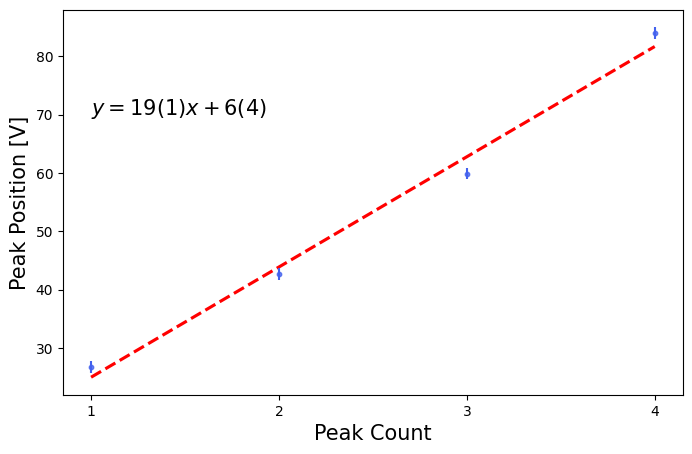

In [224]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

sns.regplot(
    x=df['x'],
    y=df['y'],
    scatter_kws={'color': '#4361ee', 's': 10, },
    line_kws={'color': 'red', 'linestyle': "--"},
    ci=None
)
ax.errorbar(
    x=df['x'],
    y=df['y'],
    yerr=1,
    color='#4361ee',
    fmt='None',
    markersize=5
)
ax.text(1, 70, r'$y = 19(1)x + 6(4)$', fontsize=fontsize)
ax.set_xlabel('Peak Count', fontsize=fontsize)
ax.set_xticks([1, 2, 3, 4])
ax.set_ylabel('Peak Position [V]', fontsize=fontsize)
plt.savefig('../tex/figures/part_5_step_4_linear_fit.png', bbox_inches='tight')

## Step 5

In [188]:
temp = step4.query('`dR/dN`.notna() and `dR/dN` != "#DIV/0!"').reset_index()
temp.head(30)

,index,second,Volt1,Volt2,clean,background,clean-back,dR/dN,Current,dCurrent
0,1069,0.00210,4.96,0.944,0.943517,0.551,0.393,3.09E+00,10.189986,21.600206
1,1070,-0.03100,5.06,0.944,0.943517,0.642,0.302,1.09E+00,10.189986,21.600206
2,1071,-0.01460,5.06,1.140,1.144522,0.642,0.503,7.10E+00,12.360840,21.600303
3,1072,-0.04790,5.16,1.750,1.747537,0.733,1.010,5.10E+00,18.873403,21.600707
4,1081,0.04340,5.56,-0.866,NaN,1.090,NaN,-6.89E+00,NaN,NaN
5,1083,0.02670,5.76,-1.470,NaN,1.270,NaN,3.11E+00,NaN,NaN
6,1085,-0.04000,5.96,-1.070,NaN,1.450,NaN,1.12E+00,NaN,NaN
7,1088,-0.02330,6.37,-1.870,NaN,1.800,NaN,-1.87E+00,NaN,NaN
8,1090,-0.04760,6.67,1.550,1.546532,2.060,-0.517,3.14E+00,16.702549,21.600554
9,1104,0.00995,9.08,-1.670,NaN,4.080,NaN,1.19E+00,NaN,NaN


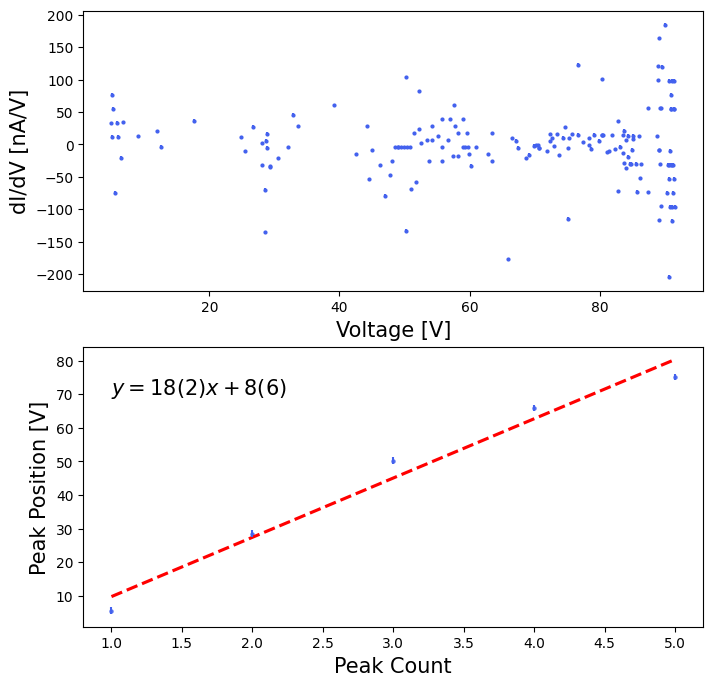

In [233]:
x = pd.to_numeric(step4['Volt1'], errors='coerce')
y = pd.to_numeric(step4['dR/dN'], errors='coerce')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.errorbar(
    x=x,
    y=y*10.8,
    yerr=2,
    color='#4361ee',
    fmt='o',
    markersize=2
)
ax1.set_xlabel('Voltage [V]', fontsize=fontsize)
ax1.set_ylabel(r'dI/dV [nA/V]', fontsize=fontsize)
sns.regplot(
    x=[1, 2, 3, 4, 5],
    y=[5.6, 28.5, 50.2, 65.9, 75.1],
    # yerr=1,
    ci=None,
    scatter_kws={'color': '#4361ee', 's': 5, },
    line_kws={'color': 'red', 'linestyle': "--"},
    ax=ax2
)
ax2.errorbar(
    x=[1, 2, 3, 4, 5],
    y=[5.6, 28.5, 50.2, 65.9, 75.1],
    yerr=1,
    fmt='None',
    color='#4361ee',
)
ax2.text(1, 70, r'$y = 18(2)x + 8(6)$', fontsize=fontsize)
ax2.set_xlabel('Peak Count', fontsize=fontsize)
ax2.set_ylabel('Peak Position [V]', fontsize=fontsize)
plt.savefig('../tex/figures/part_5_step_5.png', bbox_inches='tight')

## step 6